## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers gensim transformers tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.6 MB/s eta 0:00:00


In [ ]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# to use regular expressions for manipulating text data
import re

# to load the natural language toolkit
import nltk
nltk.download('stopwords')    # loading the stopwords
nltk.download('wordnet')    # loading the wordnet module that is used in stemming

# to remove common stop words
from nltk.corpus import stopwords

# to perform stemming
from nltk.stem.porter import PorterStemmer

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


## **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
stock_news = pd.read_csv("/content/drive/MyDrive/stock_news.csv")

In [ ]:
#Creating a copy of the dataset
stock = stock_news.copy()

## **Data Overview**

### Displaying the first few rows of the dataset

In [ ]:
stock.head(5) #checking the first 5 rows of the data

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


### Understanding the shape of the dataset

In [ ]:
stock.shape # code to check the shape of the data

(349, 8)

### Checking the data types of the columns

In [ ]:
stock.dtypes # code to check the data types

,0
Date,object
News,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Label,int64


In [ ]:
stock['Date'] = pd.to_datetime(stock['Date'])  # to convert the 'Date' column in the 'stock' DataFrame to datetime format.

### Checking the statistical summary

In [ ]:
stock.describe() #  code to check the statistical summary

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### Checking the duplicate values

In [ ]:
stock.duplicated().sum() #code to check the duplicate values

0

### Checking for missing values

In [ ]:
stock.isnull().sum() # code to check for missing values in the data

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


## **Exploratory Data Analysis**

### Univariate Analysis

#### Observations on Label

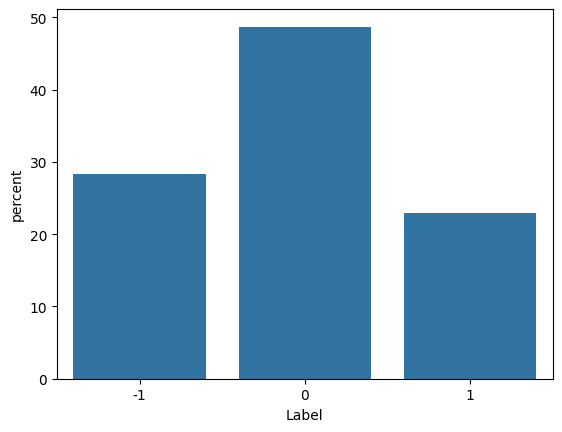

In [ ]:
sns.countplot(data=stock, x="Label", stat="percent");

**Observation**

Neutral news are close to 50% followed by negative.


#### Density Plot of Price (Open,High,Low,Close)

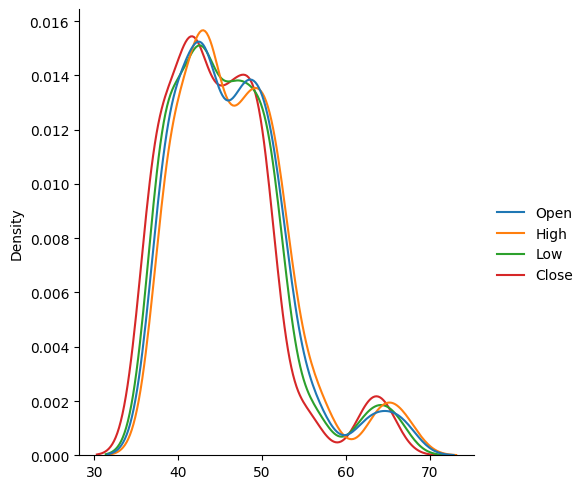

In [ ]:
sns.displot(data=stock[['Open','High','Low','Close']], kind="kde", palette="tab10"); # code to plot a density plot of ["Open","High","Low","Close"] all in a single plot

**Observation**

Price of stocks have high density between 40 - 50

#### Observations on Volume

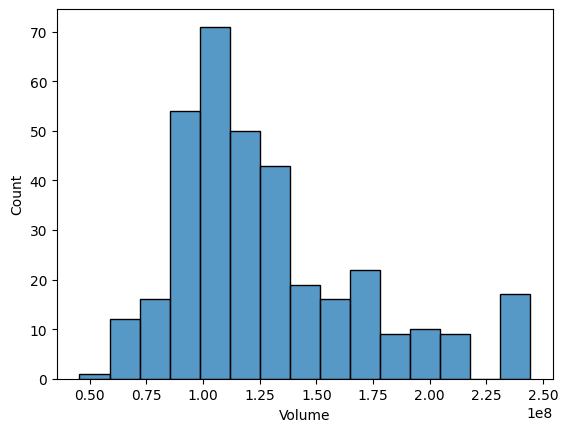

In [ ]:
sns.histplot(stock, x='Volume'); # code to plot a histogram of Volume

**Observation**

Volume is right skewed. There are few stocks that are outliers with higher volume.

#### Observations on News length

In [ ]:
#Calculating the total number of words present in the news content.
stock['news_len'] = stock['News'].apply(lambda x: len(x.split(' ')))


stock['news_len'].describe()    #code to print the statistical summary for the news content length

,news_len
count,349.000000
mean,49.312321
std,5.727770
min,19.000000
25%,46.000000
50%,50.000000
75%,53.000000
max,61.000000


**Observation**

There are 349 news. Mean words in news is 49.3

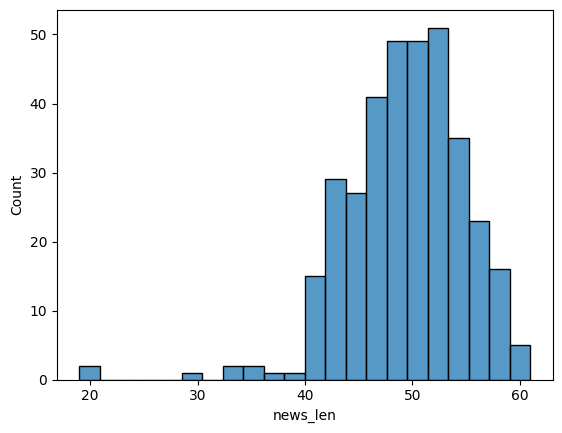

In [ ]:
sns.histplot(stock,x="news_len"); #code to plot a histogram of news_len column

**Observation**

The graph indicates left skewed distribution. There is a outlier with 20 words.

### Bivariate Analysis

#### Correlation

In [ ]:
num_col=stock.select_dtypes(include=np.number).columns

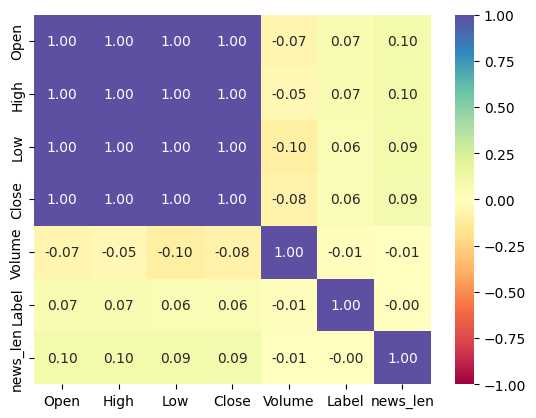

In [ ]:
  #code to plot the correlation matrix for numeric columns only.
sns.heatmap(
    stock[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

**Observation**

There are strong correlation among Open, High, Low and Close. Rst of the features don't indicate strong correlation

#### Label vs Price (Open, High, Low, Close)

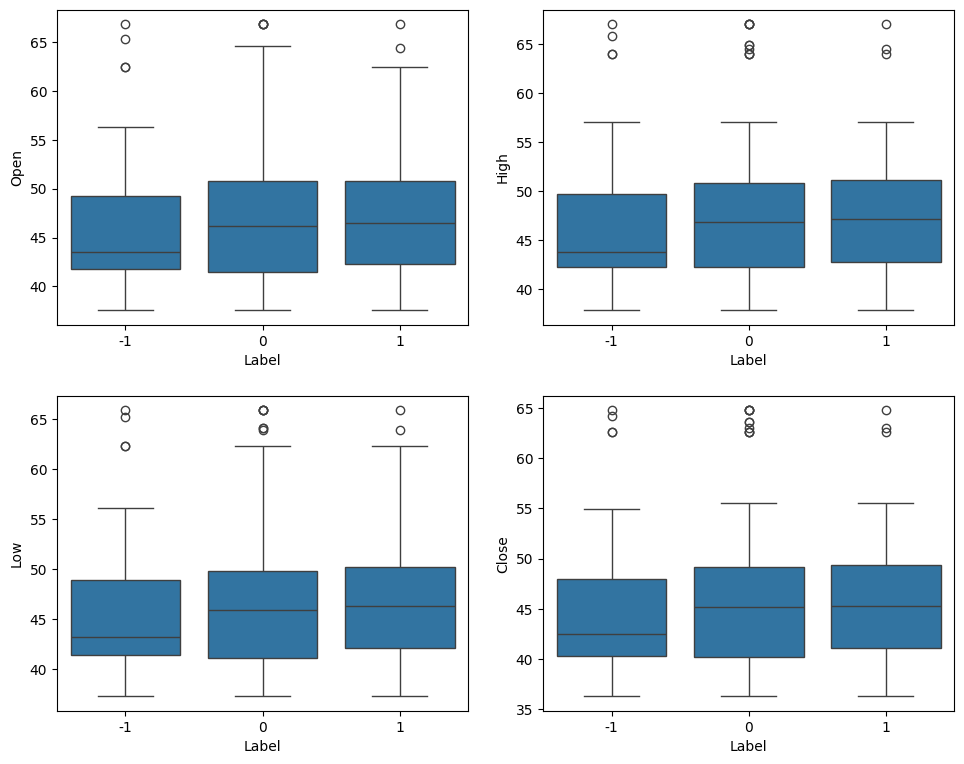

In [ ]:
plt.figure(figsize=(10, 8))

for i, variable in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=stock, x="Label", y=variable)
    plt.tight_layout(pad=2)

plt.show()

**Observation**

Negative labels have lower mean price among Open, High, Close ad Low. Positive and Neutral mean values are similar in the graphs. There are outliers in the data.

#### Label vs Volume

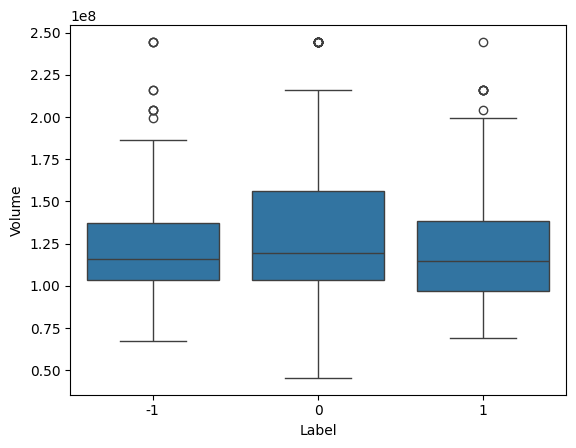

In [ ]:
sns.boxplot(
    data=stock, x="Label", y="Volume"
);

**Observation**

Neutral label stocks have slightly higher volume compared to negative and positive stocks.

#### Date vs Price (Open, High, Low, Close)

In [ ]:
stock_daily = stock.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()  # Group the 'stocks' DataFrame by the 'Date' column

stock_daily.set_index('Date', inplace=True)
stock_daily.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,41.740002,42.244999,41.482498,40.246914,130672400.0
2019-01-03,43.570000,43.787498,43.222500,42.470604,103544800.0
2019-01-04,47.910000,47.919998,47.095001,46.419842,111448000.0
2019-01-07,50.792500,51.122501,50.162498,49.110790,109012000.0
2019-01-08,53.474998,54.507500,51.685001,50.787209,216071600.0


**Observation**

As the date progresses average stock price value increases while volume fulctuates.

#### Volume vs Close Price

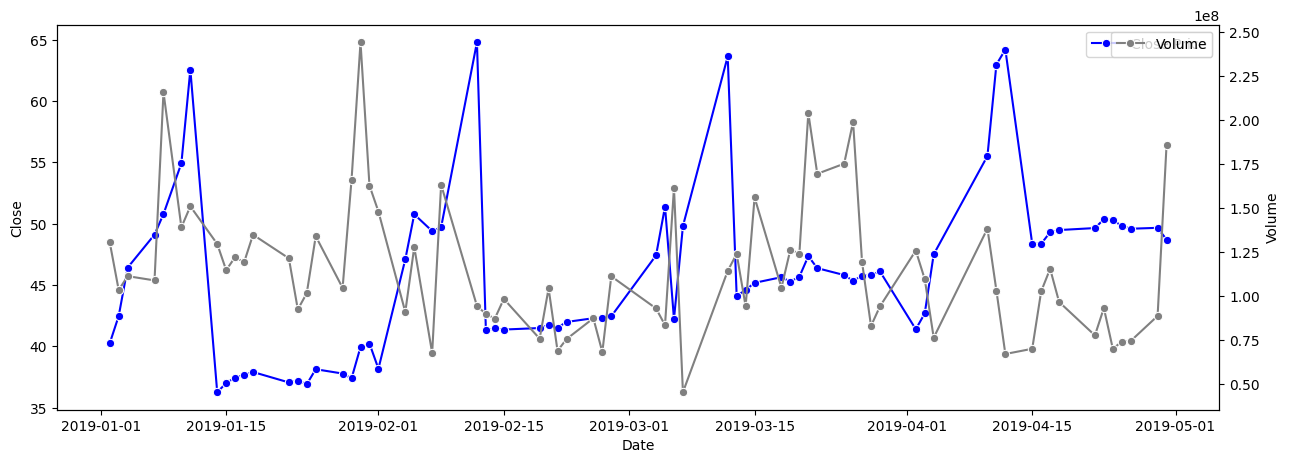

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));

**Observation**

Volume and Close price show correlation for certain dates but acts erratically on others. No conclusive correlation.

## **Data Preprocessing**

In [ ]:
stock_clean = stock.copy()

#### **Preprocessing the textual column**

In [ ]:
# Loading the Porter Stemmer
ps = PorterStemmer()

In [ ]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    text = ' '.join([word for word in words if word not in stopwords.words('english')])

    # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    text = ' '.join([ps.stem(word) for word in words])

    return text

In [ ]:
# preprocessing the textual column
stock_clean['News'] = stock_clean['News'].apply(preprocess_text)

In [ ]:
stock_clean['Date'].describe() #code to print the statistical summary of the 'Date' column

,Date
count,349
mean,2019-02-16 16:05:30.085959936
min,2019-01-02 00:00:00
25%,2019-01-14 00:00:00
50%,2019-02-05 00:00:00
75%,2019-03-22 00:00:00
max,2019-04-30 00:00:00


**Observation**

Date ranges from Jan 2019 to Apr 2019. This indicates Q1 period.

### Train-test-validation Split

In [ ]:
X_train = stock_clean[(stock_clean['Date'] < '2019-04-01')].reset_index()
X_val = stock_clean[(stock_clean['Date'] >= '2019-04-01') & (stock_clean['Date'] < '2019-04-16')].reset_index()
X_test = stock_clean[stock_clean['Date'] >= '2019-04-16'].reset_index()

**Note**

I have split the data into periods as stock moves linearly and the news are associated with date and stock movement on the day. Hence didn't randomly pick test and validation data.

In [ ]:
# code to pick the target variable
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [ ]:
#Code to print the shape of X_train,X_val,X_test,y_train,y_val and y_test
print("Train data shape",X_train.shape)
print("Validation data shape",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape",y_train.shape)
print("Validation label shape",y_val.shape)
print("Test label shape ",y_test.shape)

Train data shape (286, 10)
Validation data shape (21, 10)
Test data shape  (42, 10)
Train label shape (286,)
Validation label shape (21,)
Test label shape  (42,)


## **Word Embeddings**

### Word2Vec

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in stock_clean['News'].values]

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 2595


Let's check out a few word embeddings obtained using the model.

In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([-0.02033327,  0.10455772,  0.01075158,  0.02706786,  0.00227864,
       -0.17724945,  0.11903197,  0.3799906 ,  0.046796  , -0.03459846,
        0.02364885, -0.11852431,  0.02391192, -0.05122945, -0.11648322,
       -0.16383174,  0.0515596 , -0.02305996,  0.08988128, -0.07381959,
       -0.05014015, -0.01072509,  0.10074428,  0.0068094 ,  0.08654737,
        0.02332122, -0.1759283 ,  0.03850709, -0.0853373 , -0.14657713,
        0.00777881, -0.04639716,  0.03005324, -0.03381584, -0.03885559,
        0.079351  ,  0.07642799, -0.17371476, -0.0156662 ,  0.02033364,
       -0.09459743,  0.02812882,  0.03445831, -0.11320915,  0.06219158,
        0.12217292,  0.07449249,  0.05286939, -0.03978556,  0.11814325,
        0.03334662,  0.00940943, -0.10231096, -0.0032514 , -0.0173253 ,
        0.16662349,  0.08221015,  0.04113609,  0.09776809, -0.00448591,
       -0.0905121 , -0.01734863, -0.00258959,  0.02034535, -0.01806424,
        0.10545161, -0.03273053,  0.02900835, -0.11654452, -0.06

In [ ]:
# Checking the word embedding of a random word
word = "econom"
model_W2V.wv[word]

array([-0.01977697,  0.09625719,  0.01592084,  0.02620424,  0.00627754,
       -0.17467548,  0.11414563,  0.37104252,  0.04610366, -0.03324531,
        0.02120641, -0.11187027,  0.02075795, -0.04777557, -0.11129714,
       -0.16192889,  0.05377336, -0.02321042,  0.08495292, -0.07495594,
       -0.04531709, -0.00761003,  0.1023405 ,  0.00146623,  0.08440652,
        0.02245045, -0.17001359,  0.03853729, -0.08162259, -0.14164177,
        0.00826532, -0.04268619,  0.02300062, -0.03173453, -0.03812248,
        0.07576501,  0.07293685, -0.17061594, -0.01426145,  0.0191005 ,
       -0.0892763 ,  0.02758791,  0.0342878 , -0.10809952,  0.05923139,
        0.1203912 ,  0.07110673,  0.05359831, -0.03991751,  0.11318424,
        0.03083636,  0.01033594, -0.0984608 , -0.00120602, -0.01536159,
        0.16504364,  0.07956439,  0.04098537,  0.09467901, -0.00409215,
       -0.09053139, -0.01393508, -0.00107818,  0.01738533, -0.02017331,
        0.10622741, -0.02853461,  0.02674655, -0.11711609, -0.06

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.4229860305786133


In [ ]:
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

(286, 300) (21, 300) (42, 300)


### GloVe

In [44]:
# load the Stanford GloVe model
filename = '/content/drive/MyDrive/glove.6B.100d.txt.word2vec'
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False,limit=400000)

In [45]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 100000


Let's check out a few word embeddings.

In [46]:
# Checking the word embedding of a random word
word = "stock"
glove_model[word]

array([ 8.6341e-01,  6.9648e-01,  4.5794e-02, -9.5708e-03, -2.5498e-01,
       -7.4666e-01, -2.2086e-01, -4.4615e-01, -1.0423e-01, -9.9931e-01,
        7.2550e-02,  4.5049e-01, -5.9912e-02, -5.7837e-01, -4.6540e-01,
        4.3429e-02, -5.0570e-01, -1.5442e-01,  9.8250e-01, -8.1571e-02,
        2.6523e-01, -2.3734e-01,  9.7675e-02,  5.8588e-01, -1.2948e-01,
       -6.8956e-01, -1.2811e-01, -5.2265e-02, -6.7719e-01,  3.0190e-02,
        1.8058e-01,  8.6121e-01, -8.3206e-01, -5.6887e-02, -2.9578e-01,
        4.7180e-01,  1.2811e+00, -2.5228e-01,  4.9557e-02, -7.2455e-01,
        6.6758e-01, -1.1091e+00, -2.0493e-01, -5.8669e-01, -2.5375e-03,
        8.2777e-01, -4.9102e-01, -2.6475e-01,  4.3015e-01, -2.0516e+00,
       -3.3208e-01,  5.1845e-02,  5.2646e-01,  8.7452e-01, -9.0237e-01,
       -1.7366e+00, -3.4727e-01,  1.6590e-01,  2.7727e+00,  6.5756e-02,
       -4.0363e-01,  3.8252e-01, -3.0787e-01,  5.9202e-01,  1.3468e-01,
       -3.3851e-01,  3.3646e-01,  2.0950e-01,  8.5905e-01,  5.18

In [47]:
# Checking the word embedding of a random word
word = "economy"
glove_model[word]

array([-0.19382  ,  1.017    ,  1.076    ,  0.02954  , -0.39192  ,
       -1.3891   , -0.87873  , -0.63162  ,  0.9643   , -0.43035  ,
       -0.34868  ,  0.22736  , -0.40296  ,  0.15641  , -0.16813  ,
       -0.15343  , -0.15799  , -0.27612  ,  0.18088  , -0.28386  ,
        0.49847  ,  0.29864  ,  0.32353  ,  0.18108  , -0.59623  ,
       -0.54165  , -0.70019  , -0.64956  , -0.69063  ,  0.18084  ,
       -0.38581  ,  0.56086  , -0.40313  , -0.38777  , -0.70615  ,
        0.20657  ,  0.34171  , -0.23393  , -0.35882  , -0.2201   ,
       -0.76182  , -1.2047   ,  0.4339   ,  1.1656   ,  0.1836   ,
       -0.21601  ,  0.93198  , -0.059616 , -0.11624  , -1.3259   ,
       -0.79772  , -0.0074957, -0.0889   ,  1.4749   ,  0.31157  ,
       -2.2952   , -0.058351 ,  0.39353  ,  1.4983   ,  0.74023  ,
       -0.20109  ,  0.098124 , -0.73081  , -0.32294  ,  0.16703  ,
        0.87431  , -0.041624 , -0.51022  ,  1.0737   , -0.4257   ,
        1.0581   ,  0.19859  , -0.60087  , -0.33906  ,  0.6024

In [48]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [49]:
vec_size=100

In [50]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [51]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  5.3556694984436035


In [52]:
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape) #code to print the shapes of the final dataframes

(286, 100) (21, 100) (42, 100)


### Sentence Transformer

#### Defining the model

In [53]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Encoding the dataset

In [54]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [55]:
# encoding the dataset
start = time.time()

X_train_st = model.encode(X_train["News"].values, show_progress_bar=True, device=device)
X_val_st = model.encode(X_val["News"].values, show_progress_bar=True, device=device)
X_test_st = model.encode(X_test["News"].values, show_progress_bar=True, device=device)

end = time.time()
print("Time taken ",(end-start))

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Time taken  1.7339205741882324


In [56]:
print(X_train_st.shape, X_val_st.shape, X_test_st.shape) #code to print the shapes of the final dataframes

(286, 384) (21, 384) (42, 384)


- Each news content has been converted to a 384-dimensional vector.

## **Sentiment Analysis**

##Model Selection

For the problem statement I feel Recall score makes sense since sentiment proivded should match and there is a risk because Analysts use this to make strategic decisions.

### Utility Functions

In [57]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [58]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

### Base Model - Word2Vec

In [59]:
# Building the model

#Tried different models to see which gave better results

base_wv = GradientBoostingClassifier(random_state = 42)
#base_wv = RandomForestClassifier(random_state=42)
#base_wv = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_wv, y_train)

GradientBoostingClassifier(random_state=42)

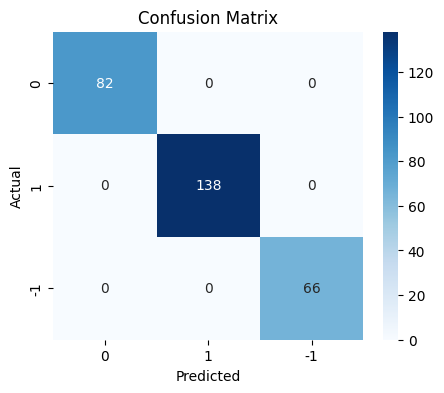

In [60]:
plot_confusion_matrix(base_wv,X_train_wv,y_train)

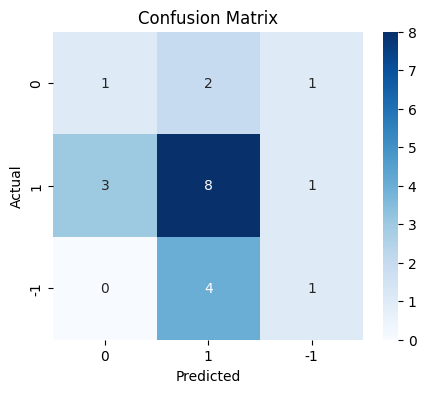

In [61]:
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [62]:
#Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [63]:
#Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.453515  0.458791


### Base Model - GloVe

In [64]:
#Building the model

#Tried different models to see which gave better results

base_gl = GradientBoostingClassifier(random_state = 42)
#base_gl = RandomForestClassifier(random_state=42)
#base_gl = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_gl.fit(X_train_gl, y_train) #Code to fit the chosen model on the train data

GradientBoostingClassifier(random_state=42)

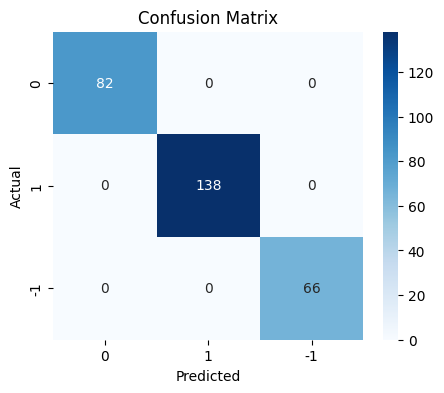

In [65]:
plot_confusion_matrix(base_gl,X_train_gl,y_train) #Code to plot the confusion matrix for the train data

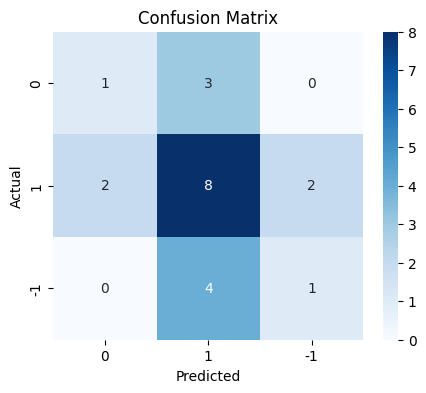

In [66]:
plot_confusion_matrix(base_gl,X_val_gl,y_val) #Code to plot the confusion matrix for the validation data

In [67]:
#Calculating different metrics on training data
base_train_gl=model_performance_classification_sklearn(base_gl,X_train_gl,y_train) #Code to compute the model performance for the training data
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [68]:
#Calculating different metrics on validation data
base_val_gl = model_performance_classification_sklearn(base_gl,X_val_gl,y_val) #Code to compute the model performance for the validation data
print("Validation performance:\n",base_val_gl)

Validation performance:
    Accuracy   Recall  Precision       F1
0   0.47619  0.47619   0.447619  0.45257


### Base Model - Sentence Transformer

In [69]:
# Building the model

#Tried different models to see which gave better results

base_st = GradientBoostingClassifier(random_state = 42)
#base_st = RandomForestClassifier(random_state=42)
#base_st = DecisionTreeClassifier(random_state=42)

# Fitting on train data
base_st.fit(X_train_st, y_train) #Code to fit the chosen model on the train data

GradientBoostingClassifier(random_state=42)

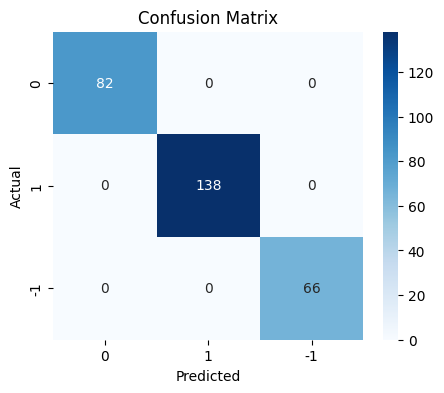

In [70]:
plot_confusion_matrix(base_st,X_train_st, y_train) #Code to plot the confusion matrix for the train data

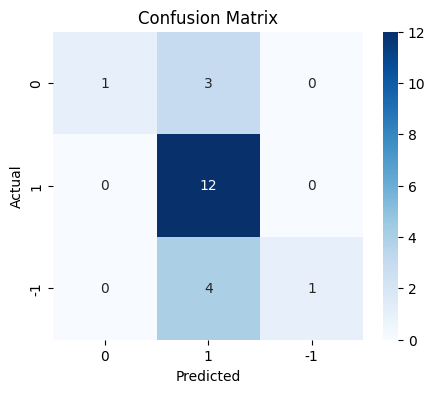

In [71]:
plot_confusion_matrix(base_st,X_val_st,y_val) #Code to plot the confusion matrix for the validation data

In [72]:
#Calculating different metrics on training data
base_train_st=model_performance_classification_sklearn(base_st,X_train_st, y_train) #Code to compute the model performance for the training data
print("Training performance:\n", base_train_st)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [73]:
#Calculating different metrics on validation data
base_val_st = model_performance_classification_sklearn(base_st,X_val_st,y_val) #Code to compute the model performance for the validation data
print("Validation performance:\n",base_val_st)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.666667  0.666667   0.789474  0.597952


**Note**

I tried 3 models. GradientBoost, Decisiontreeclassifier and RandomForestClassifier. I chose gradientboosting even though it is slower but with data being unbalanced I felt it will be better fit to provide good performance.

### Tuned Model - Word2Vec

In [75]:
start = time.time()

# Choose the type of classifier.

#Uncomment only one of the snippets corrrsponding to the base model trained previously

#tuned_wv = GradientBoostingClassifier(random_state = 42)
tuned_wv = RandomForestClassifier(random_state=42)
#tuned_wv = DecisionTreeClassifier(random_state=42)


parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv = grid_obj.best_estimator_

Time taken  136.494961977005


In [76]:
# Fit the best algorithm to the data.
tuned_wv.fit(X_train_wv, y_train)

RandomForestClassifier(max_depth=6, min_samples_split=5, random_state=42)

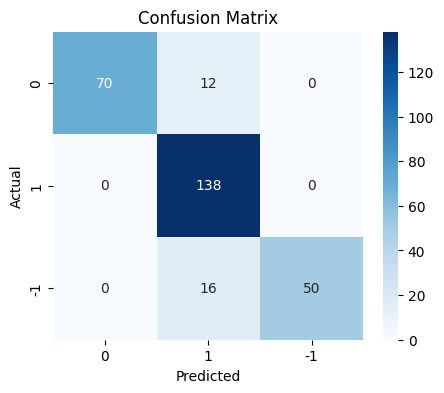

In [77]:
plot_confusion_matrix(tuned_wv,X_train_wv,y_train)

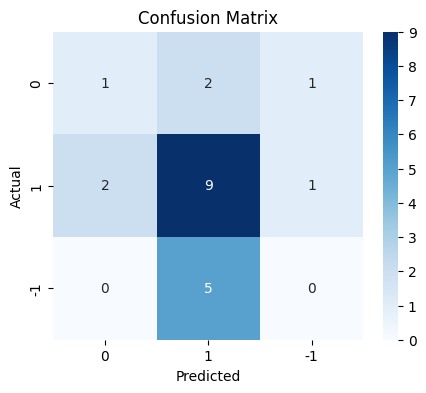

In [78]:
plot_confusion_matrix(tuned_wv,X_val_wv,y_val)

In [79]:
#Calculating different metrics on training data
tuned_train_wv=model_performance_classification_sklearn(tuned_wv,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.902098  0.902098   0.918612  0.901092


In [80]:
#Calculating different metrics on validation data
tuned_val_wv = model_performance_classification_sklearn(tuned_wv,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.384921  0.421769


### Tuned Model - GloVe

In [81]:
start = time.time()

#Tried different models to see which gave better results

#tuned_gl = GradientBoostingClassifier(random_state = 42)
tuned_gl = RandomForestClassifier(random_state=42)
#tuned_gl = DecisionTreeClassifier(random_state=42)

parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_gl, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_gl = grid_obj.best_estimator_

Time taken  88.00172710418701


In [82]:
# Fit the best algorithm to the data.
tuned_gl.fit(X_train_gl, y_train)

RandomForestClassifier(max_depth=6, max_features=0.4, min_samples_split=9,
                       random_state=42)

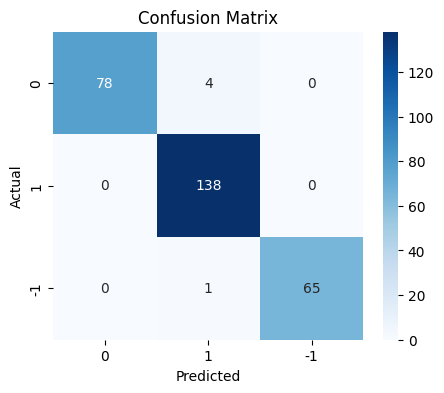

In [83]:
plot_confusion_matrix(tuned_gl,X_train_gl, y_train)

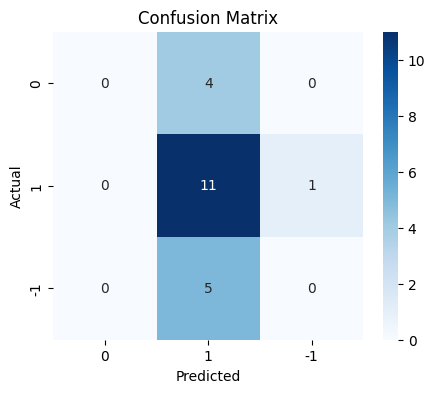

In [84]:
plot_confusion_matrix(tuned_gl,X_val_gl,y_val) #Code to plot the confusion matrix for the validation data

In [85]:
#Calculating different metrics on training data
tuned_train_gl=model_performance_classification_sklearn(tuned_gl,X_train_gl, y_train)
print("Training performance:\n",tuned_train_gl)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.982517  0.982517   0.983129  0.982485


In [86]:
#Calculating different metrics on validation data
tuned_val_gl = model_performance_classification_sklearn(tuned_gl,X_val_gl,y_val)
print("Validation performance:\n",tuned_val_gl)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.52381  0.52381   0.314286  0.392857


### Tuned Model - Sentence Transformer

In [88]:
start = time.time()

# Choose the type of classifier.

#Tried different models to see which gave better results

#tuned_st = GradientBoostingClassifier(random_state = 42)
tuned_st = RandomForestClassifier(random_state=42)
#tuned_st = DecisionTreeClassifier(random_state=42)



parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_st, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st = grid_obj.best_estimator_

Time taken  163.80462765693665


In [89]:
# Fit the best algorithm to the data.
tuned_st.fit(X_train_st, y_train)

RandomForestClassifier(max_depth=6, max_features=0.4, min_samples_split=7,
                       random_state=42)

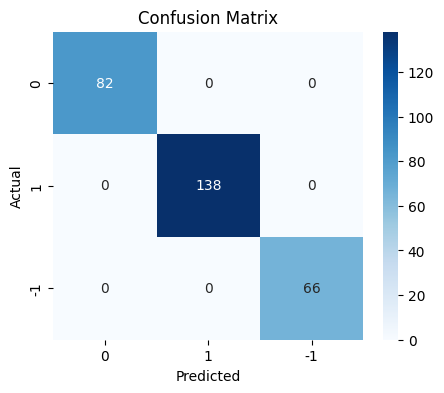

In [90]:
plot_confusion_matrix(tuned_st,X_train_st, y_train) #Code to plot the confusion matrix for the train data

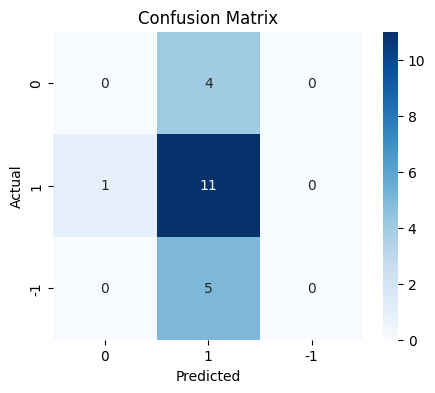

In [91]:
plot_confusion_matrix(tuned_st,X_val_st,y_val) #Code to plot the confusion matrix for the validation data

In [92]:
#Calculating different metrics on training data
tuned_train_st=model_performance_classification_sklearn(tuned_st,X_train_st, y_train)
print("Training performance:\n",tuned_train_st)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [93]:
#Calculating different metrics on validation data
tuned_val_st = model_performance_classification_sklearn(tuned_st,X_val_st,y_val)
print("Validation performance:\n",tuned_val_st)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.52381  0.52381   0.314286  0.392857


### Model Performance Summary and Final Model Selection

In [94]:
#training performance comparison

models_train_comp_df = pd.concat(
    [base_train_wv.T,
     base_train_gl.T,
     base_train_st.T,
     tuned_train_wv.T,
     tuned_train_gl.T,
     tuned_train_st.T,
    ],axis=1
)

models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,1.0,1.0,1.0,0.902098,0.982517,1.0
Recall,1.0,1.0,1.0,0.902098,0.982517,1.0
Precision,1.0,1.0,1.0,0.918612,0.983129,1.0
F1,1.0,1.0,1.0,0.901092,0.982485,1.0


In [95]:
#validation performance comparison

models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_gl.T,
     base_val_st.T,
     tuned_val_wv.T,
     tuned_val_gl.T,
     tuned_val_st.T,
     ],axis=1
)

models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,0.476190,0.476190,0.666667,0.476190,0.523810,0.523810
Recall,0.476190,0.476190,0.666667,0.476190,0.523810,0.523810
Precision,0.453515,0.447619,0.789474,0.384921,0.314286,0.314286
F1,0.458791,0.452570,0.597952,0.421769,0.392857,0.392857


### Model Performance Check on Test Data

Based on the comparison table Base model using sentence transformer delivers overall better score and I will apply to test model. Tuned model performed worse than Base Model.

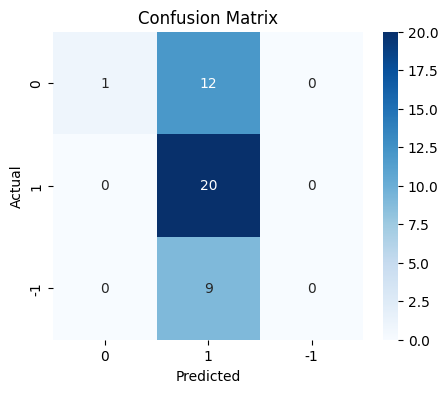

In [96]:
plot_confusion_matrix(base_st,X_test_st,y_test) #Code to plot the confusion matrix for the final model and test data

In [97]:
#Calculating different metrics on training data
final_model_test = model_performance_classification_sklearn(base_st,X_test_st,y_test) #Code to compute the final model's performance for the test data
print("Test performance for the final model:\n",final_model_test)

Test performance for the final model:
    Accuracy  Recall  Precision        F1
0       0.5     0.5   0.541812  0.356474


## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [98]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.1.85 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 164.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 150.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 155.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires numpy<2.0a0,>=1.23, but you have numpy 2.1.1 which is incompatible.
cupy-cuda12x 12.2.0 requires numpy<1.27,>=1.20, but you have numpy 2.1.1 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.1.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.1.1 which is incompatible.
p

In [99]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [100]:
stock_news = pd.read_csv("/content/drive/MyDrive/stock_news.csv") #Code to load the dataset

In [101]:
data = stock_news.copy()

#### Loading the model

In [102]:
## Model configuration
model_name_or_path = "TheBloke/Llama-2-13B-chat-GGUF"
model_basename = "llama-2-13b-chat.Q5_K_M.gguf"
model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
    )

llama-2-13b-chat.Q5_K_M.gguf:   0%|          | 0.00/9.23G [00:00<?, ?B/s]

In [103]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm_cpp = Llama(
    model_path=model_path,
    n_threads=2,  # CPU cores
    n_batch=512,  # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
    n_gpu_layers=43,  # Change this value based on your model and your GPU VRAM pool.
    n_ctx=4500, #Context window
)

AVX = 1 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


In [105]:
# model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
# model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"


# model_path = hf_hub_download(
#     repo_id=model_name_or_path, # Code to mention the repo_id
#     filename=model_basename # Code to mention the filename
#)

In [ ]:
# #uncomment the below snippet of code if the runtime is connected to GPU.
# llm = Llama(
#     model_path=model_path, # Path to the model
#     n_gpu_layers=100, #Number of layers transferred to GPU
#     n_ctx=4500, #Context window
)

In [ ]:
# uncomment and run the following code in case GPU is not being used

# llm = Llama(
#     model_path=model_path,
#     n_ctx=4500, # Context window
#     n_cores=-2 # Number of CPU cores to use
# )

#### Aggregating the data weekly

In [106]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [107]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [108]:
# Aggregate the grouped data on a weekly basis:
# concatenate 'content' values into a single string separated by ' || '.
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [109]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [110]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [111]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

##### Defining the response function

In [ ]:
# #Defining the response function
# def response_mistral_1(prompt, news):
#     model_output = llm(
#       f"""
#       [INST]
#       {prompt}
#       News Articles: {news}
#       [/INST]
#       """,
#       max_tokens=64, #Code to set the maximum number of tokens the model should generate for this task.
#       temperature=0.1, #Code to set the value for temperature.
#       top_p=0.95, #Code to set the value for top_p
#       top_k=50, #Code to set the value for top_k
#       echo=False,
#     )

#     final_output = model_output["choices"][0]["text"]

#     return final_output

In [112]:
def generate_llama_response(instruction, news):

    # System message explicitly instructing not to include the review text
    system_message = """
        [INST]<<SYS>>
        {}
        <</SYS>>[/INST]
    """.format(instruction)

    # Combine user_prompt and system_message to create the prompt
    prompt = f"{news}\n{system_message}"

    # Generate a response from the LLaMA model
    response = llm_cpp(
        prompt=prompt,
        max_tokens=1024,
        temperature=0,
        top_p=0.95,
        repeat_penalty=1.2,
        top_k=50,
        stop=['INST'],
        echo=False,
        #seed=45,
    )

    # Extract the sentiment from the response
    response_text = response["choices"][0]["text"]
    return response_text

##### Checking the model output on a sample

In [113]:
news = data_1.loc[1, 'News']

In [114]:
print(len(news.split(' ')))
news

1545


' Sprint and Samsung plan to release 5G smartphones in nine U.S. cities this summer, with Atlanta, Chicago, Dallas, Houston, Kansas City, Los Angeles, New York City, Phoenix, and Washington D.C. being the initial locations. Rival Verizon also announced similar plans for the first half of 20 ||  AMS, an Austrian tech company listed in Switzerland and a major supplier to Apple, has developed a light and infrared proximity sensor that can be placed behind a smartphone\'s screen. This allows for a larger display area by reducing the required space for sensors. AMS provides optical sensors for 3D facial recognition features on Apple ||  Deutsche Bank upgraded Vivendi\'s Universal Music Group valuation from €20 billion to €29 billion, surpassing the market cap of Vivendi at €28.3 billion. The bank anticipates music streaming revenue to reach €21 billion in 2023 and identifies potential suitors for ||  Amazon\'s stock is predicted to surge by over 20% by the end of this year, according to a n

In [115]:
#Code to define the instruction for this task
intruction_1 = """

You are an expert AI specialized in analyzing stock market news articless.

Task 1: Analyze the provided news headline and return the main topics contained within it.

Task 2: Identify the top three positive and negative events that are most likely to impact the price of the stock.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
"""

In [116]:
#Code to define the instruction for this task
instruction_2= """
    You are an AI analyzing stock market news articles.

    "Summarize the key points and main arguments presented in the news article, while providing a concise yet comprehensive overview of the information and its implications. Summary should have a minimum of 100 words and maximum of 200 words"

    Further, Identify the top three positive and three negative events or action that are most likely to impact the price of the stock.

    Provide the output in a JSON format with the following keys:
    {
        "Summary": "your_summary_prediction",
        "Week Positive Events": ["top 3 positive events"],
        "Week Negative Events": ["top 3 negative events"]
    }

    Only return the JSON, do not return any other information and remove the extra spaces.
"""

In [117]:
%%time
summary = generate_llama_response(instruction_2, news)
print(summary)

 {
            "Summary": "Apple's stock price may be impacted by a potential recession, despite optimistic trade talks and a possible pause in the Fed's policy tightening cycle. The company is set to launch three new iPhone models this year, but weak sales in China have led retailers to cut prices on previous models.",
            "Week Positive Events": ["launch of new iPhone models", "optimistic trade talks", "possible pause in the Fed's policy tightening cycle"],
            "Week Negative Events": ["disappointing holiday sales and revenue cuts", "price cuts on previous iPhone models in China"]
        }
CPU times: user 43.7 s, sys: 6.18 s, total: 49.9 s
Wall time: 31.2 s


In [118]:
# %%time
# summary = response_mistral_1(intruction_1, news)
# print(summary)

##### Checking the model output on the weekly data

In [119]:
%%time
data_1['Key Events'] = data_1['News'].progress_apply(lambda x: generate_llama_response(instruction_2,x))

100%|██████████| 18/18 [09:27<00:00, 31.54s/it]

CPU times: user 13min 39s, sys: 1min 22s, total: 15min 1s
Wall time: 9min 27s


In [120]:
data_1['Key Events'].head() #Code to print the first 5 rows of the 'Key_Events' column

,Key Events
0,"{\n ""Summary"": ""Apple's revenue warning..."
1,"{\n ""Summary"": ""Apple's stock pric..."
2,"{\n ""Summary"": ""The article discus..."
3,"{\n ""Summary"": ""The Swiss National..."
4,"{\n ""Summary"": ""Apple's stock pric..."


##### Formatting the model output

In [121]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()

       "Summary": "Apple's revenue warning led to a significant decline in Asian tech stocks, with investors seeking safe haven assets like gold and Japanese yen. The US dollar index futures also suffered losses due to the news, which caused a 5% decrease in Berkshire Hathcats stake in Apple's revenue forecast quarterly decline in iPhone sales and weaker-than-expected growth in Q1 earnings, with investors selling concerns about global economic slowdown. The company's stock price target cuts, and the US dollar Yahoo Finance, and Alibra trillion, 
       "Summary": "Apple's revenue forecast quarterly guidance, citing weaker-than-expected growth in Q1 earnings, which caused significant decline. The company's expected to be a signification of Apple's lowered the US dollar weakened demand for the previous guidance and global economic slowdown.
    "Summary": "Apple downward guidance and the quarterly guidance and weaker-quarter guidance and the quarterly guidance and the quarterly guidance 

,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,"{\n ""Summary"": ""Apple's revenue warning...",{}
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,"{\n ""Summary"": ""Apple's stock pric...",{'Summary': 'Apple's stock price may be impact...
2,2019-01-20,The U.S. stock market declined on Monday as c...,"{\n ""Summary"": ""The article discus...",{'Summary': 'The article discusses how a decli...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","{\n ""Summary"": ""The Swiss National...",{'Summary': 'The Swiss National Bank (SNB) gov...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,"{\n ""Summary"": ""Apple's stock pric...",{'Summary': 'Apple's stock price may be impact...


In [122]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

,Summary,Week Positive Events,Week Negative Events
0,NaN,NaN,NaN
1,Apple's stock price may be impacted by a poten...,"[launch of new iPhone models, optimistic trade...","[disappointing holiday sales and revenue cuts,..."
2,The article discusses how a decline in Chinese...,"[Netflix's price increase, Verizon's offer of ...","[Decline in Chinese exports and imports, Disap..."
3,"The Swiss National Bank (SNB) governor, Andrea...",[IBM's stock price increased after hours due t...,[The White House reportedly rejected a schedul...
4,Apple's stock price may be impacted by its Q1 ...,[Apple's Q1 earnings report may show a decline...,[Apple's decision to suspend production at its...


In [123]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)


In [124]:
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)


final_output.head()

,Date,News,Summary,Week Positive Events,Week Negative Events
0,2019-01-06,The tech sector experienced a significant dec...,NaN,NaN,NaN
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,Apple's stock price may be impacted by a poten...,"[launch of new iPhone models, optimistic trade...","[disappointing holiday sales and revenue cuts,..."
2,2019-01-20,The U.S. stock market declined on Monday as c...,The article discusses how a decline in Chinese...,"[Netflix's price increase, Verizon's offer of ...","[Decline in Chinese exports and imports, Disap..."
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...","The Swiss National Bank (SNB) governor, Andrea...",[IBM's stock price increased after hours due t...,[The White House reportedly rejected a schedul...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,Apple's stock price may be impacted by its Q1 ...,[Apple's Q1 earnings report may show a decline...,[Apple's decision to suspend production at its...


## **Conclusions and Recommendations**

- Conclusion
  1. We used Embedding and Transformer to do sentiment analysis of the stock news.
  2. We then created a 100 to 200 word summary of the weekly news articles using LLM.
  3. We identified 3 positive and 3 negative events in the news article using LLM that can highlight the weekly news for the stock analysts.

- Recommendation  

 To try and improve the model performance, one can try the following:
    1. Update the prompt
    2. Try different model
    3. Update the model parameters (`temparature`, `top_p`, ...)



<font size=6 color='blue'>Power Ahead</font>
___